### Import Libraries

In [1]:
import pandas as pd
import folium
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

### Import Dataset

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../input/anz-transactions-dataset/dataset.csv", index_col = "date", parse_dates = ["date"])
df.head()

,status,account,currency,long_lat,txn_description,first_name,balance,gender,age,extraction,amount,transaction_id,country,customer_id,movement,Month,Date,Day Name,longitude,latitude
date,,,,,,,,,,,,,,,,,,,,
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,POS,Diana,35.39,F,26,2018-08-01T01:01:15.000+0000,16.25,a623070bfead4541a6b0fff8a09e706c,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,21.20,F,26,2018-08-01T01:13:45.000+0000,14.19,13270a2a902145da9db4c951e04b51b9,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1222300524,AUD,151.23 -33.94,POS,Michael,5.71,M,38,2018-08-01T01:26:15.000+0000,6.42,feb79e7ecd7048a5a36ec889d1a94270,Australia,CUS-2142601169,debit,August,2018-08-01,Wednesday,151.23,-33.94
2018-08-01,authorized,ACC-1037050564,AUD,153.10 -27.66,SALES-POS,Rhonda,2117.22,F,40,2018-08-01T01:38:45.000+0000,40.90,2698170da3704fd981b15e64a006079e,Australia,CUS-1614226872,debit,August,2018-08-01,Wednesday,153.10,-27.66
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,17.95,F,26,2018-08-01T01:51:15.000+0000,3.25,329adf79878c4cf0aeb4188b4691c266,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95


### Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12043 entries, 2018-08-01 to 2018-10-31
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   status           12043 non-null  object 
 1   account          12043 non-null  object 
 2   currency         12043 non-null  object 
 3   long_lat         12043 non-null  object 
 4   txn_description  12043 non-null  object 
 5   first_name       12043 non-null  object 
 6   balance          12043 non-null  float64
 7   gender           12043 non-null  object 
 8   age              12043 non-null  int64  
 9   extraction       12043 non-null  object 
 10  amount           12043 non-null  float64
 11  transaction_id   12043 non-null  object 
 12  country          12043 non-null  object 
 13  customer_id      12043 non-null  object 
 14  movement         12043 non-null  object 
 15  Month            12043 non-null  object 
 16  Date             12043 non-null  object 


In [5]:
df.describe()

,balance,age,amount,longitude,latitude
count,12043.000000,12043.000000,12043.000000,12043.000000,12043.000000
mean,14704.195553,30.582330,187.933588,143.648563,-38.164347
std,31503.722652,10.046343,592.599934,16.669352,54.622791
min,0.240000,18.000000,0.100000,114.620000,-573.000000
25%,3158.585000,22.000000,16.000000,138.690000,-37.700000
50%,6432.010000,28.000000,29.000000,145.230000,-33.890000
75%,12465.945000,38.000000,53.655000,151.220000,-30.750000
max,267128.520000,78.000000,8835.980000,255.000000,-12.370000


**Remove unnecessary columns**

### Data Analysis and Visualizations

**Average Tansaction Amount**

In [6]:
print("Average Transaction Amount =", np.round(df["amount"].mean(), 2))

Average Transaction Amount = 187.93


**Number of Transctions by Customers Each Month**

In [7]:
df["Month"] = df.index.month_name()
atm = df.groupby("Month")["Month"].agg(["count"])
atm.columns = ["Total Transactions"]
atm

,Total Transactions
Month,
August,3943
October,4087
September,4013


In [8]:
print("Average Number of Transactions by Customers Each Month =", np.round(atm["Total Transactions"].mean(), 2))

Average Number of Transactions by Customers Each Month = 4014.33


**Number of Transactions by Date**

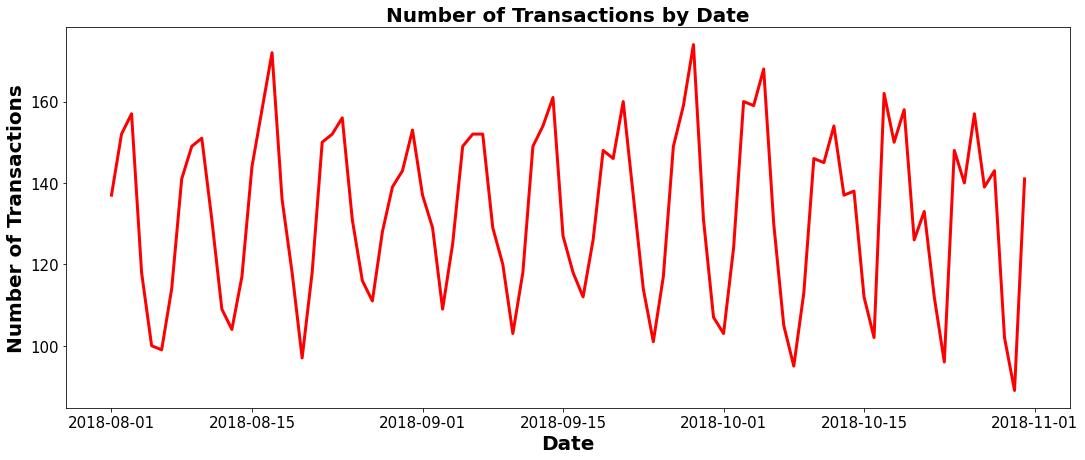

In [9]:
df["Date"] = df.index
td = df.groupby("Date")["Date"].agg(["count"])

plt.figure(figsize = (18, 7))
sns.lineplot(x = td.index, y = "count", data = td, color = "red", linewidth = 3)
plt.title("Number of Transactions by Date", weight = "bold", size = 20)
plt.xlabel("Date", weight = "bold", size = 20)
plt.ylabel("Number of Transactions", weight = "bold", size = 20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

**Average Transactions Amount by Date**

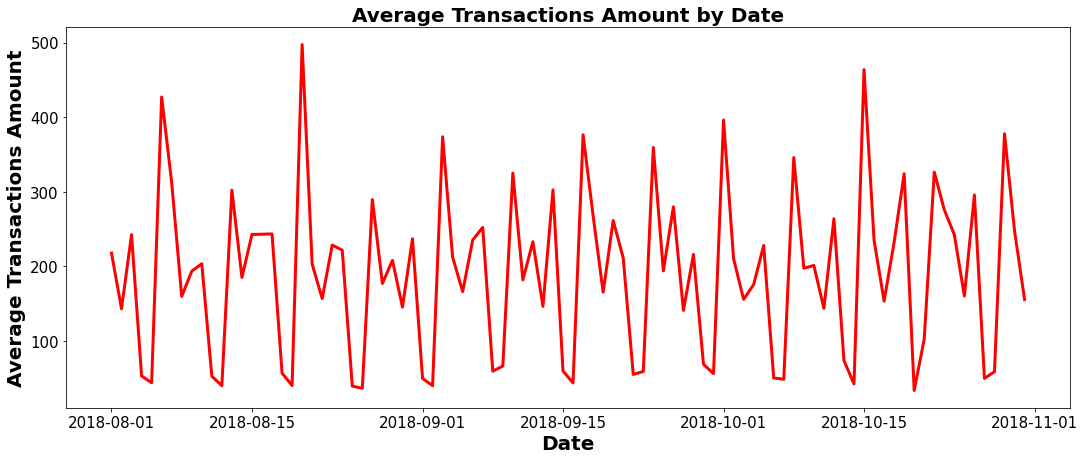

In [10]:
tmd = df.groupby("Date")["amount"].agg(["mean"])

plt.figure(figsize = (18, 7))
sns.lineplot(x = tmd.index, y = "mean", data = tmd, color = "red", linewidth = 3)
plt.title("Average Transactions Amount by Date", weight = "bold", size = 20)
plt.xlabel("Date", weight = "bold", size = 20)
plt.ylabel("Average Transactions Amount", weight = "bold", size = 20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

**Number of Transactions by Day Name**

In [11]:
df["Day Name"] = df.index.day_name()
atd = df.groupby("Day Name")["Day Name"].agg(["count"])
atd

,count
Day Name,
Friday,2073
Monday,1360
Saturday,1709
Sunday,1550
Thursday,1801
Tuesday,1487
Wednesday,2063


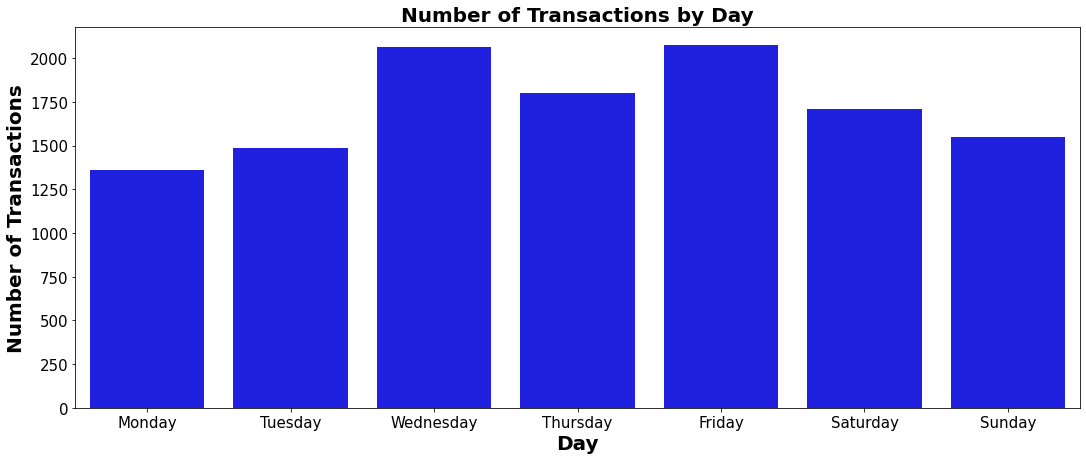

In [12]:
plt.figure(figsize = (18, 7))
atd = atd.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
sns.barplot(x = atd.index, y = "count", data = atd, color = "blue")
plt.title("Number of Transactions by Day", weight = "bold", size = 20)
plt.xlabel("Day", weight = "bold", size = 20)
plt.ylabel("Number of Transactions", weight = "bold", size = 20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

**Average Transactions amount by Day Name**

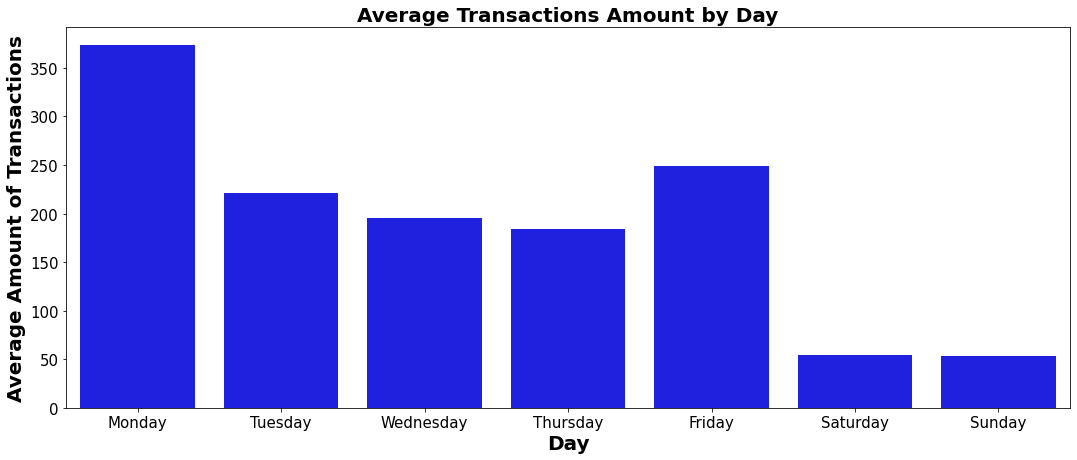

In [13]:
atdn = df.groupby("Day Name")["amount"].agg(["mean"])
atdn = atdn.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.figure(figsize = (18, 7))
sns.barplot(x = atdn.index, y = "mean", data = atdn, color = "blue")
plt.title("Average Transactions Amount by Day", weight = "bold", size = 20)
plt.xlabel("Day", weight = "bold", size = 20)
plt.ylabel("Average Amount of Transactions", weight = "bold", size = 20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

**Number of Transacrions by Month and Day**

In [14]:
atmd = df.groupby(["Month", "Day Name"])["Day Name"].agg(["count"]).reset_index()
atmd_pivot = pd.pivot_table(index = "Month", columns = ["Day Name"], values = "count", data = atmd)
atmd_pivot = atmd_pivot[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]] 
atmd_pivot = atmd_pivot.reindex(["August", "September", "October"])
atmd_pivot

Day Name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Month,,,,,,,
August,411,477,711,596,789,516,443
September,425,486,595,611,647,661,588
October,524,524,757,594,637,532,519


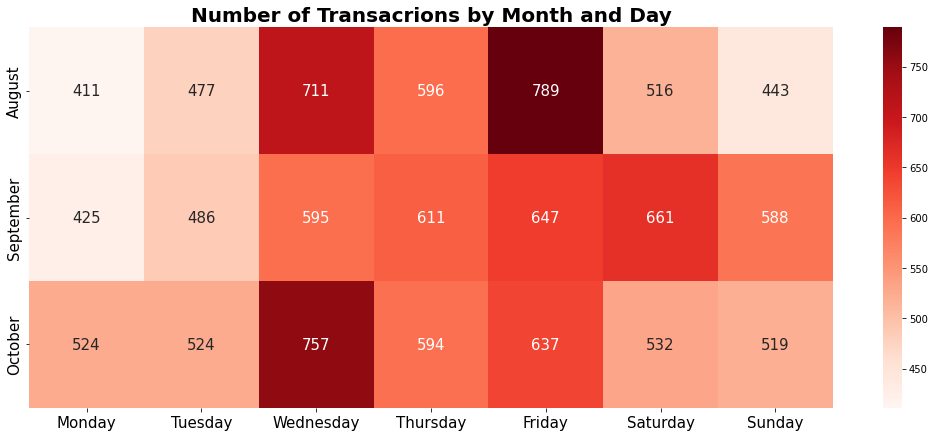

In [15]:
plt.figure(figsize = (18, 7))
plt.title("Number of Transacrions by Month and Day", size = 20, weight = "bold")
sns.heatmap(atmd_pivot, annot = True, cmap = "Reds", fmt = "g", annot_kws={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel(None)
plt.ylabel(None)
plt.show()

**Average Amount of Transacrions by Month and Day**

In [16]:
avtmd = df.groupby(["Month", "Day Name"])["amount"].agg(["mean"]).reset_index().round()
avtmd_pivot = pd.pivot_table(index = "Month", columns = ["Day Name"], values = "mean", data = avtmd)
avtmd_pivot = avtmd_pivot[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]] 
avtmd_pivot = avtmd_pivot.reindex(["August", "September", "October"])
avtmd_pivot

Day Name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Month,,,,,,,
August,375.0,218.0,197.0,178.0,230.0,51.0,40.0
September,359.0,215.0,211.0,195.0,245.0,59.0,53.0
October,383.0,231.0,181.0,179.0,277.0,53.0,64.0


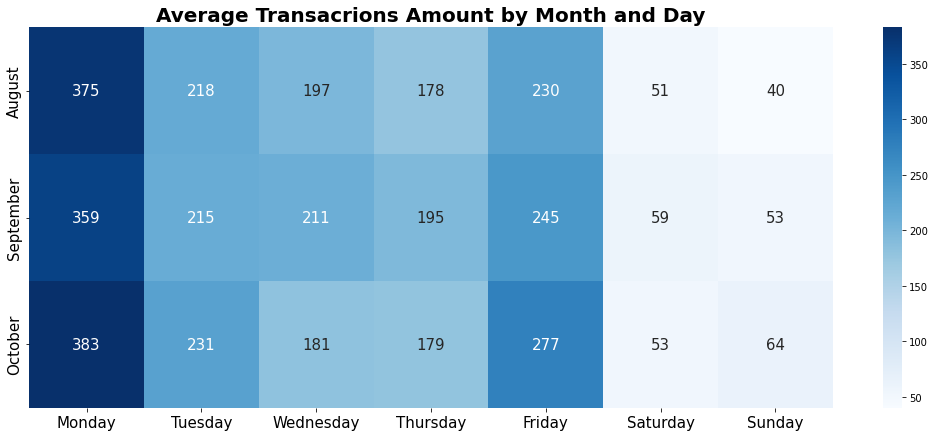

In [17]:
plt.figure(figsize = (18, 7))
plt.title("Average Transacrions Amount by Month and Day", size = 20, weight = "bold")
sns.heatmap(avtmd_pivot, annot = True, cmap = "Blues", fmt = "g", annot_kws={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel(None)
plt.ylabel(None)
plt.show()

In [18]:
df.head()

,status,account,currency,long_lat,txn_description,first_name,balance,gender,age,extraction,amount,transaction_id,country,customer_id,movement,Month,Date,Day Name,longitude,latitude
date,,,,,,,,,,,,,,,,,,,,
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,POS,Diana,35.39,F,26,2018-08-01T01:01:15.000+0000,16.25,a623070bfead4541a6b0fff8a09e706c,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,21.20,F,26,2018-08-01T01:13:45.000+0000,14.19,13270a2a902145da9db4c951e04b51b9,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1222300524,AUD,151.23 -33.94,POS,Michael,5.71,M,38,2018-08-01T01:26:15.000+0000,6.42,feb79e7ecd7048a5a36ec889d1a94270,Australia,CUS-2142601169,debit,August,2018-08-01,Wednesday,151.23,-33.94
2018-08-01,authorized,ACC-1037050564,AUD,153.10 -27.66,SALES-POS,Rhonda,2117.22,F,40,2018-08-01T01:38:45.000+0000,40.90,2698170da3704fd981b15e64a006079e,Australia,CUS-1614226872,debit,August,2018-08-01,Wednesday,153.10,-27.66
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,17.95,F,26,2018-08-01T01:51:15.000+0000,3.25,329adf79878c4cf0aeb4188b4691c266,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95


In [19]:
df["longitude"] = df["long_lat"].str.split(" ").str.get(0)
df["latitude"] = df["long_lat"].str.split(" ").str.get(1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12043 entries, 2018-08-01 to 2018-10-31
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   status           12043 non-null  object        
 1   account          12043 non-null  object        
 2   currency         12043 non-null  object        
 3   long_lat         12043 non-null  object        
 4   txn_description  12043 non-null  object        
 5   first_name       12043 non-null  object        
 6   balance          12043 non-null  float64       
 7   gender           12043 non-null  object        
 8   age              12043 non-null  int64         
 9   extraction       12043 non-null  object        
 10  amount           12043 non-null  float64       
 11  transaction_id   12043 non-null  object        
 12  country          12043 non-null  object        
 13  customer_id      12043 non-null  object        
 14  movement         1204

In [21]:
df

,status,account,currency,long_lat,txn_description,first_name,balance,gender,age,extraction,amount,transaction_id,country,customer_id,movement,Month,Date,Day Name,longitude,latitude
date,,,,,,,,,,,,,,,,,,,,
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,POS,Diana,35.39,F,26,2018-08-01T01:01:15.000+0000,16.25,a623070bfead4541a6b0fff8a09e706c,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,21.20,F,26,2018-08-01T01:13:45.000+0000,14.19,13270a2a902145da9db4c951e04b51b9,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
2018-08-01,authorized,ACC-1222300524,AUD,151.23 -33.94,POS,Michael,5.71,M,38,2018-08-01T01:26:15.000+0000,6.42,feb79e7ecd7048a5a36ec889d1a94270,Australia,CUS-2142601169,debit,August,2018-08-01,Wednesday,151.23,-33.94
2018-08-01,authorized,ACC-1037050564,AUD,153.10 -27.66,SALES-POS,Rhonda,2117.22,F,40,2018-08-01T01:38:45.000+0000,40.90,2698170da3704fd981b15e64a006079e,Australia,CUS-1614226872,debit,August,2018-08-01,Wednesday,153.10,-27.66
2018-08-01,authorized,ACC-1598451071,AUD,153.41 -27.95,SALES-POS,Diana,17.95,F,26,2018-08-01T01:51:15.000+0000,3.25,329adf79878c4cf0aeb4188b4691c266,Australia,CUS-2487424745,debit,August,2018-08-01,Wednesday,153.41,-27.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-10-31,authorized,ACC-3021093232,AUD,149.83 -29.47,POS,Melissa,14054.14,F,30,2018-10-31T23:09:06.000+0000,9.79,f2e3e695c2ee4c50a4c8747f852cbe2e,Australia,CUS-55310383,debit,October,2018-10-31,Wednesday,149.83,-29.47
2018-10-31,authorized,ACC-1608363396,AUD,151.22 -33.87,SALES-POS,Robert,9137.79,M,20,2018-10-31T23:21:46.000+0000,63.87,56e147e5485f4683b9076fcaaed76640,Australia,CUS-2688605418,debit,October,2018-10-31,Wednesday,151.22,-33.87
2018-10-31,authorized,ACC-3827517394,AUD,151.12 -33.89,POS,Craig,45394.57,M,28,2018-10-31T23:34:25.000+0000,43.96,2fdd4681827343f6af2e6519644a684a,Australia,CUS-2663907001,debit,October,2018-10-31,Wednesday,151.12,-33.89


In [22]:
df["longitude"] = df["longitude"].astype("float")

In [23]:
df["latitude"] = df["latitude"].astype("float")

In [24]:
!pip install folium

### Total Transactions Amount by Area

In [25]:
from folium import plugins

australia_map = folium.Map(location = [-25, 133], zoom_start = 4)

area = plugins.MarkerCluster().add_to(australia_map)

for lat, lng, label, in zip(df["latitude"], df["longitude"], df["amount"]):
    folium.Marker(
        location=[lat, lng],
        icon=None,
    ).add_to(area)


australia_map